## Clustering Model using the Kickstart datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("kickstarter_combined.csv")
df.head()

,backers_count,blurb,category,converted_pledged_amount,country,country_displayable_name,created_at,creator,currency,currency_symbol,...,spotlight,staff_pick,state,state_changed_at,static_usd_rate,urls,usd_exchange_rate,usd_pledged,usd_type,video
0,20,A photographic book of a festival celebrated b...,"{""id"":278,""name"":""People"",""analytics_name"":""Pe...",637.0,GB,the United Kingdom,1724064660,"{""id"":729000581,""name"":""Neil Martinson"",""slug""...",GBP,£,...,False,False,failed,1727098184,1.320305,"{""web"":{""project"":""https://www.kickstarter.com...",1.330982,632.425889,domestic,"{""id"":1312771,""status"":""successful"",""hls"":""htt..."
1,531,Unlock the Full Potential of Your Steam Deck w...,"{""id"":52,""name"":""Hardware"",""analytics_name"":""H...",83872.0,US,the United States,1746583126,"{""id"":767329947,""name"":""Seesaw"",""slug"":""dockca...",USD,$,...,False,True,live,1761051614,1.000000,"{""web"":{""project"":""https://www.kickstarter.com...",1.000000,83872.000000,domestic,"{""id"":1367591,""status"":""successful"",""hls"":""htt..."
2,0,Retagger Mobile: Transform the Internet with S...,"{""id"":332,""name"":""Apps"",""analytics_name"":""Apps...",0.0,US,the United States,1731435583,"{""id"":1696039535,""name"":""Donnie Bugden"",""slug""...",USD,$,...,False,False,live,1760906735,1.000000,"{""web"":{""project"":""https://www.kickstarter.com...",1.000000,0.000000,domestic,"{""id"":1392212,""status"":""successful"",""hls"":""htt..."
3,166,Help support the making and release of Armchai...,"{""id"":37,""name"":""Country & Folk"",""analytics_na...",12314.0,US,the United States,1548701666,"{""id"":1417057582,""name"":""Armchair Boogie"",""slu...",USD,$,...,True,True,successful,1559659892,1.000000,"{""web"":{""project"":""https://www.kickstarter.com...",1.000000,12314.860000,domestic,"{""id"":955599,""status"":""successful"",""hls"":""http..."
4,66,When you buy MatchBack's premier graphic tee &...,"{""id"":263,""name"":""Apparel"",""analytics_name"":""A...",5599.0,US,the United States,1496003666,"{""id"":2025826474,""name"":""Aaron Podell"",""is_reg...",USD,$,...,True,False,successful,1498892340,1.000000,"{""web"":{""project"":""https://www.kickstarter.com...",1.000000,5599.000000,domestic,"{""id"":787581,""status"":""successful"",""hls"":null,..."


## Data Prep

#### Standardize "Goal" Based on USD

In [3]:
# Use static_usd_rate for goal
df['goal_usd_static'] = df['goal'] * df['static_usd_rate']

# As we use static_rate, we drop fx_rate and used columns
df = df.drop(columns=['goal', 'static_usd_rate', 'fx_rate'])

#### Campaign, Preparation Duration Calculation

In [4]:
df['campaign_duration_days'] = (df['deadline'] - df['launched_at']) / (24*3600)
df['preparation_duration_days'] = (df['launched_at'] - df['created_at']) / (24*3600)

# We drop used columns
df = df.drop(columns=['deadline', 'launched_at', 'created_at'])

#### Check Length of Name and Description

In [6]:
df['name_len'] = df['name'].fillna('').apply(len)
df['blurb_len'] = df['blurb'].fillna('').apply(len)

# We drop used columns
df = df.drop(columns=['name', 'blurb'])

#### Check "Video", "Photo" Columns and Convert them into Integer

In [7]:
# If there is any variable, it means the project has a video/photo
df['has_video'] = df['video'].notna().astype(int)
df['has_photo'] = df['photo'].notna().astype(int)
    
# We drop used columns
df = df.drop(columns=['video', 'photo'])

In [8]:
df.shape

(229598, 39)

In [9]:
df['has_photo'].sum()

229598

In [10]:
df['has_video'].sum()

154421

In [11]:
# As all rows have photo (no difference amongst valeus), we drop the column
df = df.drop(columns=['has_photo'])

#### Remove Not Important Columns for Clusteriung

In [12]:
df.columns

Index(['backers_count', 'category', 'converted_pledged_amount', 'country',
       'country_displayable_name', 'creator', 'currency', 'currency_symbol',
       'currency_trailing_code', 'current_currency', 'disable_communication',
       'id', 'is_disliked', 'is_in_post_campaign_pledging_phase',
       'is_launched', 'is_liked', 'is_starrable', 'location', 'percent_funded',
       'pledged', 'prelaunch_activated', 'profile', 'slug', 'source_url',
       'spotlight', 'staff_pick', 'state', 'state_changed_at', 'urls',
       'usd_exchange_rate', 'usd_pledged', 'usd_type', 'goal_usd_static',
       'campaign_duration_days', 'preparation_duration_days', 'name_len',
       'blurb_len', 'has_video'],
      dtype='object')

In [13]:
# Meaningful columns
num_cols = [
    'backers_count',
    'goal_usd_static',
    'campaign_duration_days',
    'preparation_duration_days',
    'name_len',
    'blurb_len',
    'has_video',   
    'percent_funded'                       
]

# Non-critical columns
non_critic_cols = [
    'usd_pledged',                           # duplicate info (reflected in 'backers_count')
    'converted_pledged_amount',              # duplicate info (captured in 'usd_pledged')
    'country_displayable_name',              # duplicate info (captued in 'country')
    'creator',                               # not important for clustering
    'currency',                              # not important to draw business insight
    'currency_symbol',                       # not important to draw business insight
    'currency_trailing_code',                # not important to draw business insight
    'current_currency',                      # not important to draw business insight
    'id',                                    # not important to draw business insight
    'is_in_post_campaign_pledging_phase',    # not important to draw business insight
    'is_starrable',                          # whether the project can be starred, it can be quite subjective
    'location',                              # not important for clustering
    'is_disliked',                           # duplicate info (reflected in 'backers_count')
    'is_liked',                              # duplicate info (reflected in 'backers_count')
    'pledged',                               # duplicate info (captured in 'usd_pledged')
    'profile',                               # not important for clustering
    'slug',                                  # not important for clustering
    'source_url',                            # not important to draw business insight
    'spotlight',                             # whether the project can be spotlighted when succeed, not important
    'state_changed_at',                      # not important to draw business insight
    'urls',                                  # not important to draw business insight
    'usd_exchange_rate',                     # duplicate info
    'usd_type',                              # duplicate info
    'is_launched',                           # not important to draw business insight
    'prelaunch_activated',                   # not important for clustering
    'disable_communication',                 # not important for clustering
    'staff_pick',                            # initially included, but was not meaningful to draw biz insight  
    'country',                               # External factor, not project's own charateristics
    'category',                              # PCA is needed if included, and hard to interpret 
    'state'
]  

In [14]:
df = df.drop(columns=non_critic_cols)
df.head()

,backers_count,percent_funded,goal_usd_static,campaign_duration_days,preparation_duration_days,name_len,blurb_len,has_video
0,20,31.933333,1980.456855,27.00000,8.110012,16,90,1
3,166,102.623833,12000.000000,35.00000,91.831319,49,71,1
4,66,111.980000,5000.000000,22.08691,11.346817,46,130,1
5,156,211.620000,7700.857800,38.00000,128.156493,42,124,1
9,327,126.455143,22661.000000,30.00000,94.860810,53,127,1


In [15]:
df.dtypes

backers_count                  int64
percent_funded               float64
goal_usd_static              float64
campaign_duration_days       float64
preparation_duration_days    float64
name_len                       int64
blurb_len                      int64
has_video                      int64
dtype: object

#### Check Correlation Among Numerical Columns
Because the K-Means clustering method is distance-based, two variables that carry highly identical information (namely, have a high correlation) can disproportionately influence the distance metric, potentially distorting the resulting cluster structure.

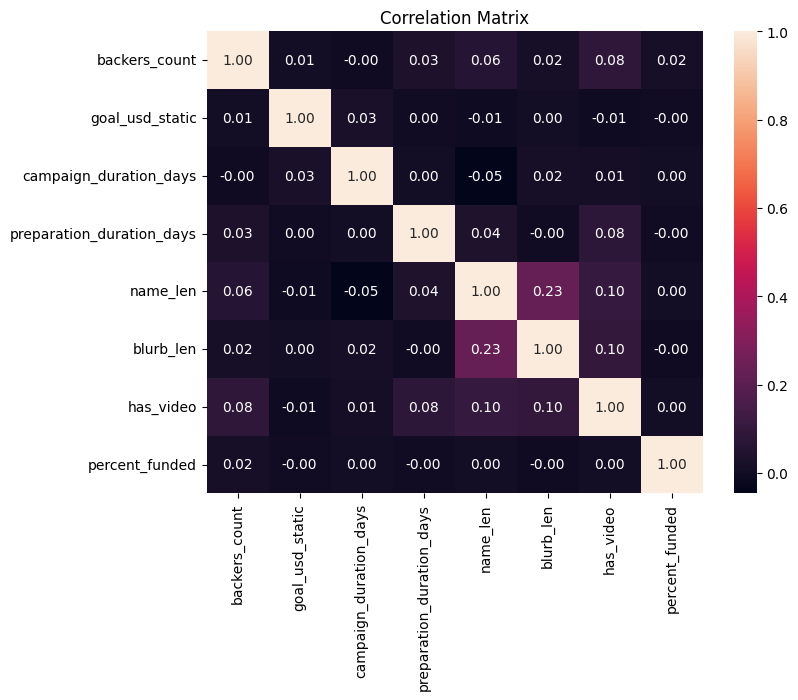

In [16]:
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

#### Standardize Numerical Columns

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df[num_cols].describe()

,backers_count,goal_usd_static,campaign_duration_days,preparation_duration_days,name_len,blurb_len,has_video,percent_funded
count,2.295980e+05,2.295980e+05,2.295980e+05,2.295980e+05,2.295980e+05,2.295980e+05,2.295980e+05,2.295980e+05
mean,1.188375e-17,-8.177812e-18,5.839437e-16,-4.012311e-17,1.431310e-18,3.724502e-17,-1.028609e-16,4.222366e-18
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00
min,-1.925629e-01,-3.336663e-02,-2.522140e+00,-3.498225e-01,-2.227955e+00,-3.289377e+00,-1.433213e+00,-1.403105e-02
25%,-1.834714e-01,-3.207448e-02,-2.842981e-01,-3.228458e-01,-8.163528e-01,-6.597355e-01,-1.433213e+00,-1.385665e-02
50%,-1.484041e-01,-2.898840e-02,-2.414552e-01,-2.557329e-01,1.777597e-02,3.857845e-01,6.977331e-01,-1.221868e-02
75%,-6.008646e-02,-2.193589e-02,1.756760e-01,-6.366684e-02,9.160684e-01,8.293385e-01,6.977331e-01,-1.129881e-02
max,1.372933e+02,1.453130e+02,6.882908e+00,2.936341e+01,3.161800e+00,1.494669e+00,6.977331e-01,2.655503e+02


## K-Means Clustering

#### K-Means Labeling

In [18]:
from sklearn.cluster import KMeans

k_range = range(2, 16) 
inertia_values = []   # empty list to add inertia values for each K

for k in k_range:
    kmeans = KMeans(n_clusters=k, 
                    n_init='auto', 
                    random_state=42)
    kmeans.fit(df)
    inertia_values.append(kmeans.inertia_)
    
kmeans.labels_

array([11,  0, 14, ...,  2, 14,  4], dtype=int32)

#### Inertia plot (Elbow)

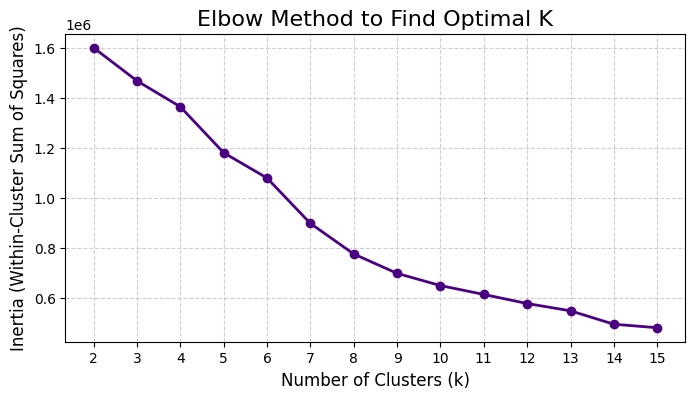

In [19]:
plt.figure(figsize=(8, 4))

plt.plot(list(k_range), inertia_values, marker='o', linestyle='-', color='indigo', linewidth=2)

plt.title('Elbow Method to Find Optimal K', fontsize=16)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(list(k_range))
plt.grid(True, linestyle='--', alpha=0.6)


plt.show()

#### Silhouette Scores
For time efficiency, I utilize samples (size of 10,000) here.

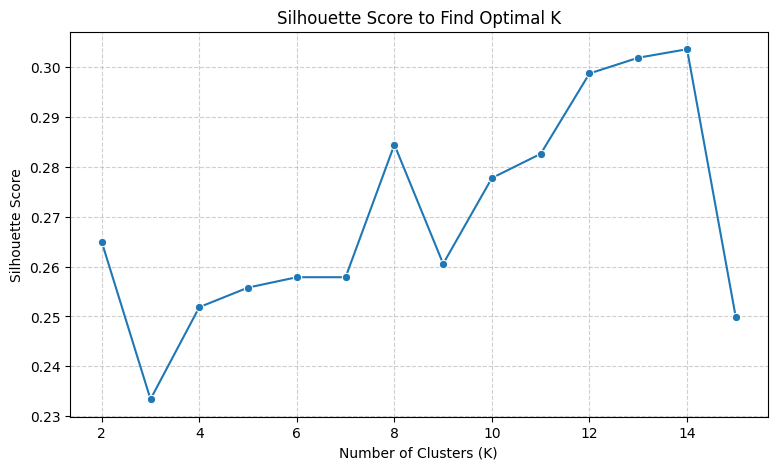

In [20]:
from sklearn.metrics import silhouette_score 

k_range_sil = range(2, 16)
silhouette_scores = []

for k in k_range_sil:
    kmeans_temp = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans_temp.fit(df)
    score = silhouette_score(df, kmeans_temp.labels_, sample_size=10000, random_state=42)  
    silhouette_scores.append(score)
    

plt.figure(figsize=(9, 5))
sns.lineplot(x=list(k_range_sil), y=silhouette_scores, marker='o')
plt.title('Silhouette Score to Find Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Apply the Optimal K
Considering the results from both the Elbow method and the Silhouette scores, the candidate values for K include **3, 4, 5, and 8.** Since the two metrics provide conflicting guidance for some of these cluster counts, I will generate a heat map for each K to examine the structure more closely. At the same time, having too many clusters can make it difficult to derive practical business insights. With this in mind, I will compare the outcomes across the candidate values and select the K that offers the most meaningful and interpretable insights.

In [21]:
optimal_k = 3

kmeans_final = KMeans(n_clusters=optimal_k, 
                      n_init='auto', 
                      random_state=42)

kmeans_final.fit(df)

cluster_counts = pd.Series(kmeans_final.labels_).value_counts().sort_index()
cluster_counts

0    72728
1    81923
2    74947
Name: count, dtype: int64

#### Create a Heat Map of the Cluster Centers (K=3)

<Axes: >

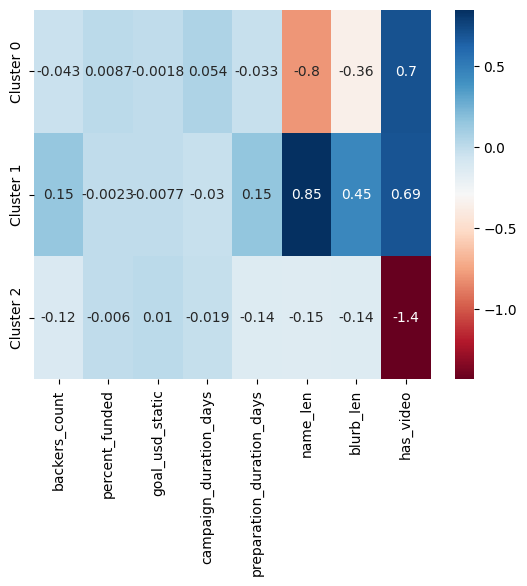

In [22]:
cluster_centers = kmeans_final.cluster_centers_

feature_names = df.columns.tolist()


cluster_centers_df = pd.DataFrame(
    cluster_centers,
    columns=feature_names,
    index=[f'Cluster {i}' for i in range(cluster_centers.shape[0])]
)

sns.heatmap(cluster_centers_df, cmap='RdBu', annot=True)

#### Create a Heat Map of the Cluster Centers (K=4)

In [25]:
optimal_k = 4

kmeans_final = KMeans(n_clusters=optimal_k, 
                      n_init='auto', 
                      random_state=42)

kmeans_final.fit(df)

cluster_counts = pd.Series(kmeans_final.labels_).value_counts().sort_index()
cluster_counts

0    62761
1    72614
2    61683
3    32540
Name: count, dtype: int64

<Axes: >

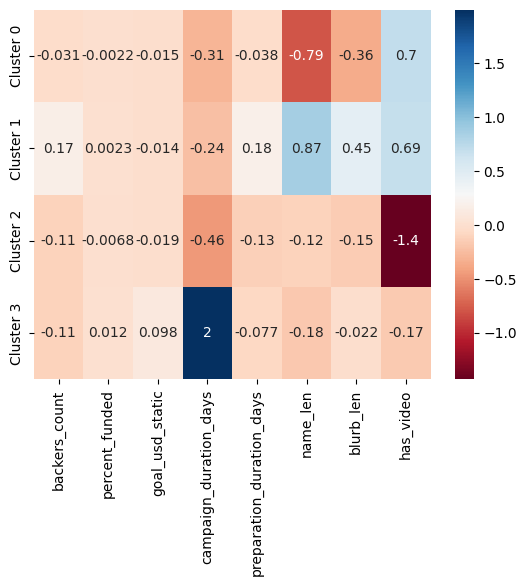

In [26]:
cluster_centers = kmeans_final.cluster_centers_

feature_names = df.columns.tolist()


cluster_centers_df = pd.DataFrame(
    cluster_centers,
    columns=feature_names,
    index=[f'Cluster {i}' for i in range(cluster_centers.shape[0])]
)

sns.heatmap(cluster_centers_df, cmap='RdBu', annot=True)

#### Create a Heat Map of the Cluster Centers (K=5)

In [27]:
optimal_k = 5

kmeans_final = KMeans(n_clusters=optimal_k, 
                      n_init='auto', 
                      random_state=42)

kmeans_final.fit(df)

cluster_counts = pd.Series(kmeans_final.labels_).value_counts().sort_index()
cluster_counts

0    62720
1    72577
2    61686
3    32587
4       28
Name: count, dtype: int64

<Axes: >

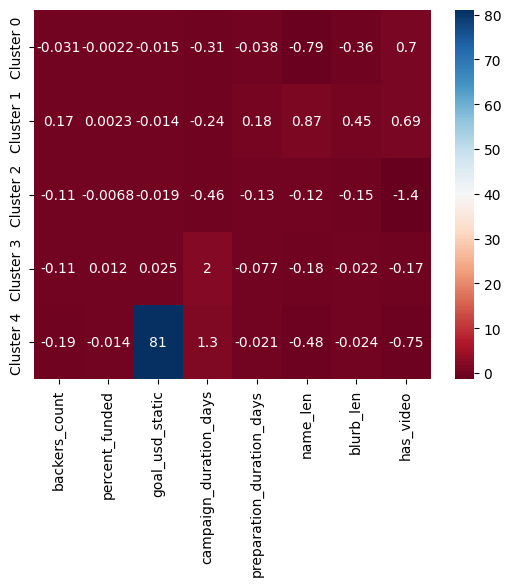

In [28]:
cluster_centers = kmeans_final.cluster_centers_

feature_names = df.columns.tolist()


cluster_centers_df = pd.DataFrame(
    cluster_centers,
    columns=feature_names,
    index=[f'Cluster {i}' for i in range(cluster_centers.shape[0])]
)

sns.heatmap(cluster_centers_df, cmap='RdBu', annot=True)

#### Create a Heat Map of the Cluster Centers (K=8)

In [29]:
optimal_k = 8

kmeans_final = KMeans(n_clusters=optimal_k, 
                      n_init='auto', 
                      random_state=42)

kmeans_final.fit(df)

cluster_counts = pd.Series(kmeans_final.labels_).value_counts().sort_index()
cluster_counts

0    41741
1    99368
2    53107
3       28
4    32277
5     2541
6        3
7      533
Name: count, dtype: int64

<Axes: >

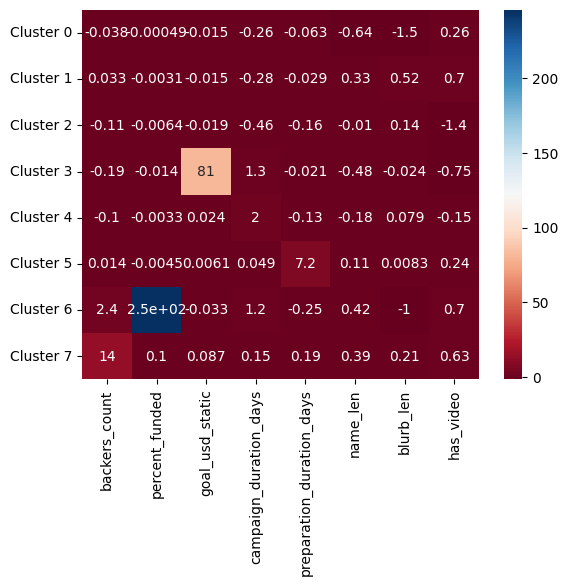

In [30]:
cluster_centers = kmeans_final.cluster_centers_

feature_names = df.columns.tolist()


cluster_centers_df = pd.DataFrame(
    cluster_centers,
    columns=feature_names,
    index=[f'Cluster {i}' for i in range(cluster_centers.shape[0])]
)

sns.heatmap(cluster_centers_df, cmap='RdBu', annot=True)

## Conclusion

As the number of clusters (K) increases, it becomes more difficult to identify distinctive characteristics across groups. Compared with K=5 and K=8, smaller values such as K=3 and K=4 produce clusters with much clearer differentiation. Since the goal of this analysis is to derive meaningful segments that distinguish projects based on selected features, it is more appropriate to focus on K values that return interpretable structure (K=3, K=4).

When comparing the heatmaps for K=3 and K=4, several issues appeared with the 4-cluster solution. The additional Cluster 3 is driven almost entirely by goal_usd_static and campaign_duration_days, suggesting that this is a noise cluster rather than a strategically meaningful segment. Meanwhile, the remaining clusters (0, 1, and 2) closely resemble the structure already present in the K=3 solution. Because these added distinctions do not translate into clearer insights, the overall segmentation becomes harder to interpret—adding complexity without offering stronger strategic value. For these reasons, selecting K=3 is the more beneficial choice.

## Interpretation

**Based on the heatmap for K=3, the clusters can be named as follows:**

- Cluster 0: Visual-Focused Campaigns with Brief Text Explanation
- Cluster 1: Rich-Content Campaigns
- Cluster 2: Simple and Minimal-Content Campaigns Without Visual Aids


**Cluster Characteristics are:**
- Cluster 0:

A value of +0.70 for has_video indicates active use of video, while the negative values for blurb_len (–0.36) and name_len (–0.80) show that text descriptions are relatively minimal. Other variables such as backers_count, goal, and duration are not particularly distinctive. Overall, this cluster represents campaigns that rely heavily on visual content while keeping text to a minimum. Interestingly, these projects still attract a notable number of backers, suggesting they may belong to categories—such as art or music—where extensive verbal explanation is less necessary.

- Cluster 1:

This group exhibits the richest content overall. Blurb_len (+0.85) is the highest across all clusters, and the positive value for name_len (+0.45) indicates detailed descriptive titles. Visual materials are also actively utilized (has_video +0.69). The cluster shows the highest number of backers (backers_count +0.15) and tends to have longer preparation periods. This segment reflects well-prepared campaigns with comprehensive information, likely associated with categories where detailed explanation and strong storytelling are essential—such as technology or complex creative projects.

- Cluster 2:

The has_video value of –1.40 indicates that this group does not use video at all. Additionally, both name_len and blurb_len are around –0.14, suggesting minimal text description. This cluster has the lowest backers_count, indicating limited appeal. It also shows the smallest preparation_duration_days, implying that these campaigns may be created by new users or by creators simply testing the market with minimal effort.


**Business Insights for New Kickstarter Creators:**

The findings clearly indicate that the type, volume, and quality of content are associated with the number of backers and overall project success. New creators should ensure that their project pages include at least one strong form of explanation-either textual or visual. While the choice between text and video may depend on the project's category, campaigns that combine both tend to perform better.

In categories where information is complex or requires careful explanation, richer content and supporting visuals are especially important. For creators experimenting with early-stage concepts or small-scale ideas, adjusting the level of textual and visual content can offer valuable insight into how different promotional approaches influence audience response.